In [44]:
import re
import unicodedata

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [45]:
# Data import + basic info
file_path = "mtsamples.csv"
df = pd.read_csv(file_path)

info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB


In [46]:
# First rows
head = df.head()

In [47]:
# null values check
missing = df.isnull().sum()

# number of records and columns
shape = df.shape

shape, missing, head

((4999, 6),
 Unnamed: 0              0
 description             0
 medical_specialty       0
 sample_name             0
 transcription          33
 keywords             1068
 dtype: int64,
    Unnamed: 0                                        description  \
 0           0   A 23-year-old white female presents with comp...   
 1           1           Consult for laparoscopic gastric bypass.   
 2           2           Consult for laparoscopic gastric bypass.   
 3           3                             2-D M-Mode. Doppler.     
 4           4                                 2-D Echocardiogram   
 
              medical_specialty                                sample_name  \
 0         Allergy / Immunology                         Allergic Rhinitis    
 1                   Bariatrics   Laparoscopic Gastric Bypass Consult - 2    
 2                   Bariatrics   Laparoscopic Gastric Bypass Consult - 1    
 3   Cardiovascular / Pulmonary                    2-D Echocardiogram - 1    
 4   

In [48]:
# Medical specialty distribution
specialty_counts = df['medical_specialty'].value_counts().sort_values(ascending=False)
num_specialties = specialty_counts.shape[0]

# Top 15 specialties
top_specialties = specialty_counts.head(15)

num_specialties, top_specialties

(40,
 medical_specialty
 Surgery                          1103
 Consult - History and Phy.        516
 Cardiovascular / Pulmonary        372
 Orthopedic                        355
 Radiology                         273
 General Medicine                  259
 Gastroenterology                  230
 Neurology                         223
 SOAP / Chart / Progress Notes     166
 Obstetrics / Gynecology           160
 Urology                           158
 Discharge Summary                 108
 ENT - Otolaryngology               98
 Neurosurgery                       94
 Hematology - Oncology              90
 Name: count, dtype: int64)

In [49]:
df["medical_specialty"].unique()

array([' Allergy / Immunology', ' Bariatrics',
       ' Cardiovascular / Pulmonary', ' Neurology', ' Dentistry',
       ' Urology', ' General Medicine', ' Surgery', ' Speech - Language',
       ' SOAP / Chart / Progress Notes', ' Sleep Medicine',
       ' Rheumatology', ' Radiology', ' Psychiatry / Psychology',
       ' Podiatry', ' Physical Medicine - Rehab',
       ' Pediatrics - Neonatal', ' Pain Management', ' Orthopedic',
       ' Ophthalmology', ' Office Notes', ' Obstetrics / Gynecology',
       ' Neurosurgery', ' Nephrology', ' Letters',
       ' Lab Medicine - Pathology', ' IME-QME-Work Comp etc.',
       ' Hospice - Palliative Care', ' Hematology - Oncology',
       ' Gastroenterology', ' ENT - Otolaryngology', ' Endocrinology',
       ' Emergency Room Reports', ' Discharge Summary',
       ' Diets and Nutritions', ' Dermatology',
       ' Cosmetic / Plastic Surgery', ' Consult - History and Phy.',
       ' Chiropractic', ' Autopsy'], dtype=object)

In [50]:
# Cleaning specialties: removing spaces, standardizing upper/lower case
df['medical_specialty'] = df['medical_specialty'].str.strip()

# Removing non-medical specialties
non_medical_specialties = [
    "Consult - History and Phy.",
    "SOAP / Chart / Progress Notes",
    "Discharge Summary",
    "Letters",
    "IME/QME",
    "Office Notes",
    "Speech - Language",
    "Pain Management",
    "Podiatry",
    "Chiropractic",
    "Emergency Room Reports",
    "Physical Medicine - Rehab",
    "IME-QME-Work Comp etc."
]
df_clean = df[~df['medical_specialty'].isin(non_medical_specialties)].copy()

# Renaming
rename_map = {
    "Cosmetic / Plastic Surgery": "Surgery",
    "Psychiatry / Psychology": "Psychiatry",
    "Pediatrics - Neonatal": "Pediatrics",
    "Cardiovascular / Pulmonary": "Cardiology / Pulmonology"
}

df_clean["medical_specialty"] = df_clean["medical_specialty"].replace(rename_map)
renamed_specialties = sorted(df_clean["medical_specialty"].unique())

renamed_specialties


['Allergy / Immunology',
 'Autopsy',
 'Bariatrics',
 'Cardiology / Pulmonology',
 'Dentistry',
 'Dermatology',
 'Diets and Nutritions',
 'ENT - Otolaryngology',
 'Endocrinology',
 'Gastroenterology',
 'General Medicine',
 'Hematology - Oncology',
 'Hospice - Palliative Care',
 'Lab Medicine - Pathology',
 'Nephrology',
 'Neurology',
 'Neurosurgery',
 'Obstetrics / Gynecology',
 'Ophthalmology',
 'Orthopedic',
 'Pediatrics',
 'Psychiatry',
 'Radiology',
 'Rheumatology',
 'Sleep Medicine',
 'Surgery',
 'Urology']

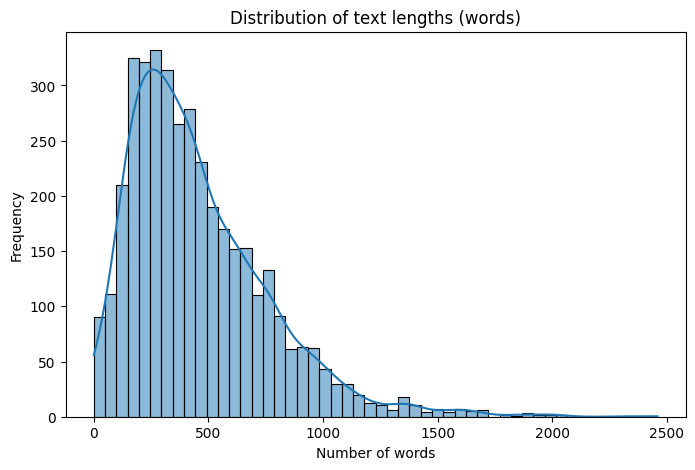

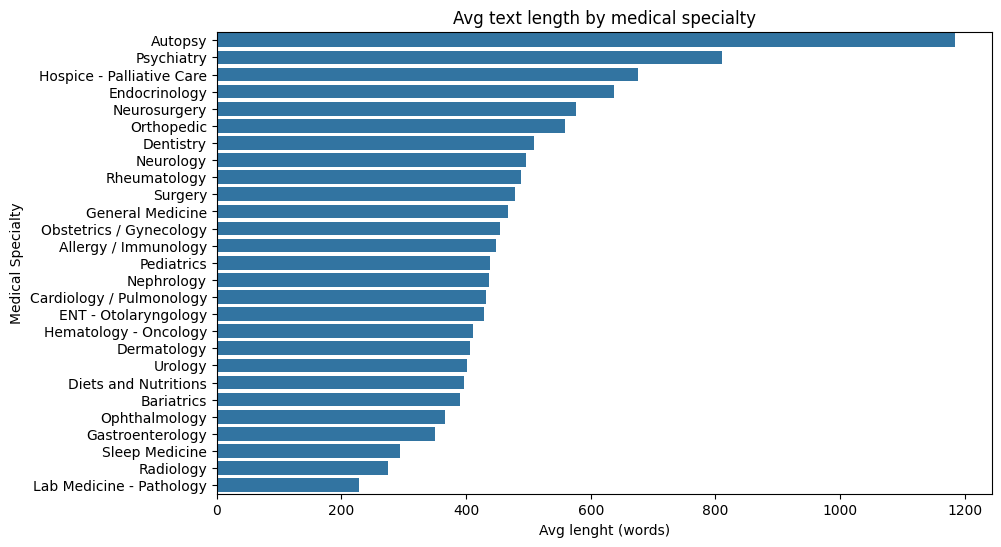

(count    3891.000000
 mean      456.042920
 std       307.832621
 min         0.000000
 25%       235.000000
 50%       390.000000
 75%       614.000000
 max      2460.000000
 Name: text_length, dtype: float64,
 medical_specialty
 Autopsy                      1184.250000
 Psychiatry                    810.792453
 Hospice - Palliative Care     676.166667
 Endocrinology                 637.842105
 Neurosurgery                  576.946809
 Orthopedic                    559.123944
 Dentistry                     509.074074
 Neurology                     496.309417
 Rheumatology                  488.000000
 Surgery                       479.243363
 Name: text_length, dtype: float64,
 medical_specialty
 Surgery                     1130
 Cardiology / Pulmonology     372
 Orthopedic                   355
 Radiology                    273
 General Medicine             259
 Gastroenterology             230
 Neurology                    223
 Obstetrics / Gynecology      160
 Urology              

In [51]:
# Text length (words)
df_clean["text_length"] = df_clean["transcription"].fillna("").apply(lambda x: len(str(x).split()))

# Global descriptive statistics
text_length_stats = df_clean["text_length"].describe()

# Avg length by specialty
avg_length_by_specialty = df_clean.groupby("medical_specialty")["text_length"].mean().sort_values(ascending=False)

# Class distribution
class_distribution = df_clean["medical_specialty"].value_counts()

# Lenghts distribution plot
plt.figure(figsize=(8,5))
sns.histplot(df_clean["text_length"], bins=50, kde=True)
plt.title("Distribution of text lengths (words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

# Avg length by specialty plot
plt.figure(figsize=(10,6))
sns.barplot(avg_length_by_specialty, orient='h')
plt.title("Avg text length by medical specialty")
plt.xlabel("Avg lenght (words)")
plt.ylabel("Medical Specialty")
plt.show()

text_length_stats, avg_length_by_specialty.head(10), class_distribution.head(10)


In [52]:
# Text field creation: description + transcription
df_clean["description"] = df_clean["description"].fillna("").astype(str)
df_clean["transcription"] = df_clean["transcription"].fillna("").astype(str)
df_clean["text"] = (df_clean["description"] + " " + df_clean["transcription"]).str.strip()

In [53]:
# Text cleaning function (with punctuation)
_ctrl_chars_re  = re.compile(r"[\x00-\x08\x0b-\x1f\x7f]")
_multi_space_re = re.compile(r"\s+")

def clean_text_for_bert(t: str) -> str:
    if not isinstance(t, str):
        t = str(t) if t is not None else ""
    t = unicodedata.normalize("NFKC", t)
    t = _ctrl_chars_re.sub(" ", t)
    t = t.replace("\n", " ").replace("\r", " ")
    t = _multi_space_re.sub(" ", t).strip()
    return t

df_clean["text"] = df_clean["text"].apply(clean_text_for_bert)

In [54]:
# Filtering by word count and removing duplicates
def word_count(s: str) -> int:
    return 0 if not s else len(s.split())

df_clean["word_count"] = df_clean["text"].apply(word_count)

min_words, max_words = 10, 3000
df_clean = df_clean[(df_clean["word_count"] >= min_words) & (df_clean["word_count"] <= max_words)].copy()
df_clean = df_clean.drop_duplicates(subset=["text"]).copy()

In [55]:
# Final dataset export
keep_cols = ["medical_specialty", "text"]

out = df_clean[keep_cols].rename(columns={"medical_specialty": "label"}).reset_index(drop=True)
out.to_csv("mtsamples_clean.csv", index=False)

print("✅ Pulizia completata.")
print(f"Righe finali: {len(out)}")
print(f"Classi finali: {out['label'].nunique()}")
print(out['label'].value_counts().head(15))

✅ Pulizia completata.
Righe finali: 2254
Classi finali: 27
label
Surgery                     982
Radiology                   247
General Medicine            228
Urology                     156
Cardiology / Pulmonology    106
Neurology                    77
Orthopedic                   73
Psychiatry                   53
Pediatrics                   53
Hematology - Oncology        44
Gastroenterology             39
Obstetrics / Gynecology      31
Nephrology                   25
ENT - Otolaryngology         22
Sleep Medicine               20
Name: count, dtype: int64
